In [1]:
import os
import cv2
import torch
import random
import numpy as np
from PIL import Image
from copy import deepcopy
import matplotlib.pyplot as plt

/Users/riccardomusmeci/Developer/code/github/saldet/venv/lib/python3.10/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def apply_saliency_map(
    image: Image,
    saliency_map: Image,
    colormap = cv2.COLORMAP_VIRIDIS,
    alpha = .3
):
    # apply the supplied color map to the heatmap and then
    # overlay the heatmap on the input image
    img = np.array(image)
    saliency_map = np.array(saliency_map)
    saliency_map = np.stack([saliency_map, saliency_map, saliency_map], axis=-1)
    saliency_map = cv2.applyColorMap(saliency_map, colormap)
    output = cv2.addWeighted(img, alpha, saliency_map, 1 - alpha, 0)
    
    return output

### **Images and Saliency Maps Dir**

In [3]:
images_dir = ""
saliency_maps_dir = ""

Loading all images and saliency maps paths

In [4]:
saliency_maps = os.listdir(saliency_maps_dir)
images = os.listdir(images_dir)
print(len(images), len(saliency_maps))

5019 5019


### **Plotting Random Maps**

In [11]:
image_name = random.choice(images)
image_no_ext = os.path.splitext(image_name)[0]
for sal_map in saliency_maps:
    if os.path.splitext(sal_map)[0] == image_no_ext:
        break
image_path = os.path.join(images_dir, image_name)
saliency_map_path = os.path.join(saliency_maps_dir, sal_map)

In [12]:
image = Image.open(image_path)
saliency_map = Image.open(saliency_map_path).resize(image.size)

Text(0.5, 1.0, 'Saliency Map Over Image')

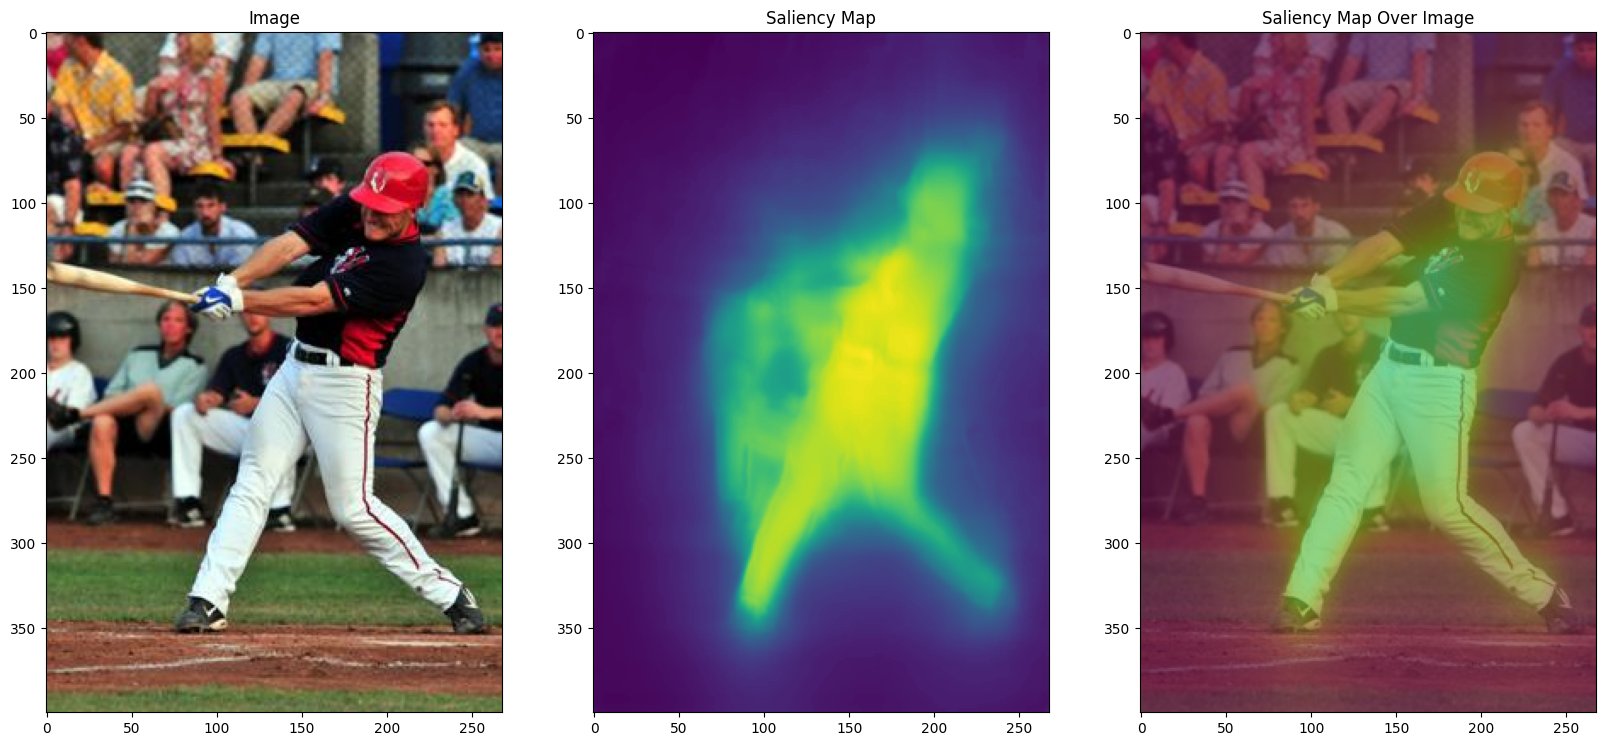

In [13]:
f, axarr = plt.subplots(1, 3, figsize=(20, 9))

axarr[0].imshow(image)
axarr[0].set_title("Image")

axarr[1].imshow(saliency_map)
axarr[1].set_title("Saliency Map")

axarr[2].imshow(apply_saliency_map(image, saliency_map))
axarr[2].set_title("Saliency Map Over Image")